In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

In [3]:
def model_builder(reg, name):
    import joblib
    joblib.dump(reg, name+'.pkl')
    return 'done!'

In [4]:
df = pd.read_csv('../data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Deleting Outliers

In [5]:
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

In [6]:
# defining the features

features = [
    'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 
    '1stFlrSF', 'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 
    'GarageArea', 'GarageYrBlt', 'YearRemodAdd', 'LotArea', 'Fireplaces'
]

In [7]:
# defining the x and y (question and answer)
x = df[features].copy()
y = df['SalePrice'].copy()

## Before cleaning

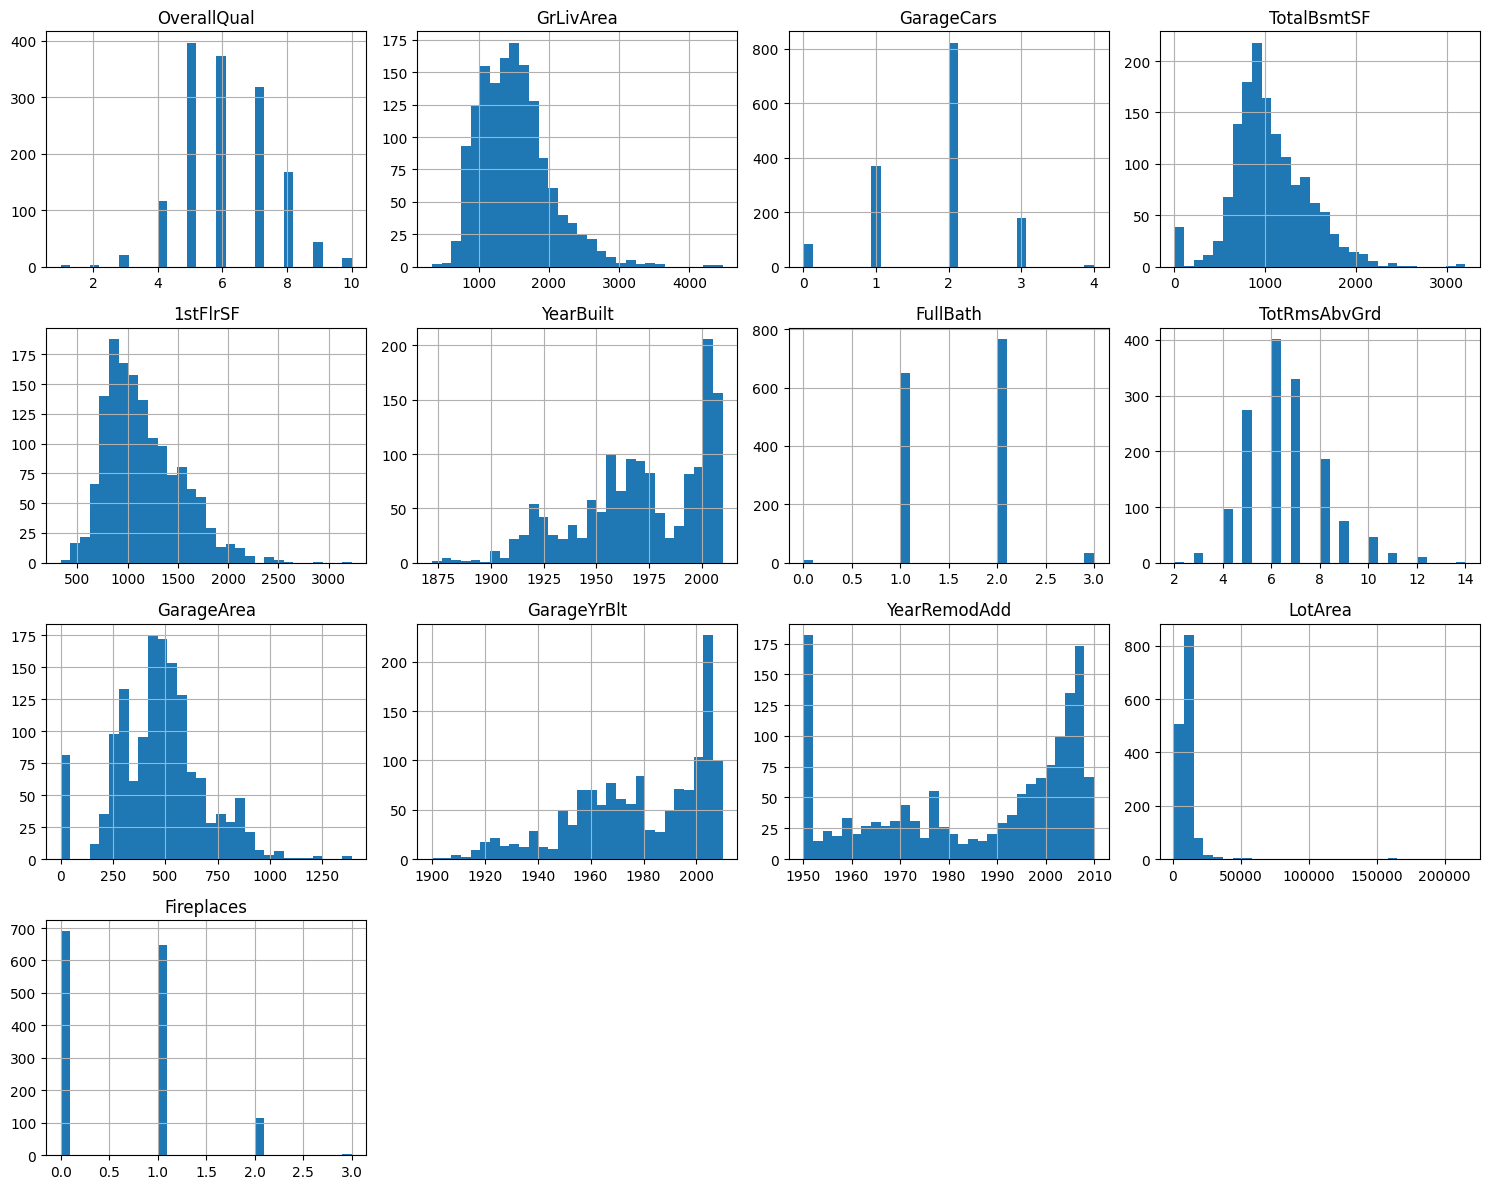

In [8]:
df[features].hist(
    figsize=(15, 12),
    bins=30
);
plt.tight_layout()
plt.show()

In [9]:
skewed_features = ['GrLivArea', '1stFlrSF', 'LotArea']
for feat in skewed_features:
    x[feat] = np.log1p(x[feat])

In [10]:
y_log = np.log1p(y)

<Axes: >

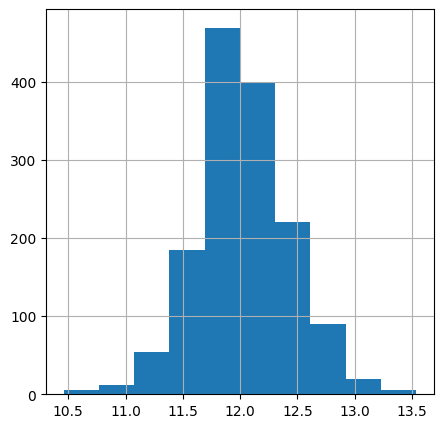

In [11]:
y_log.hist(
    figsize=(5, 5)
)

In [12]:
x_train, x_test, y_train_log, y_test_log = train_test_split(x, y_log, test_size=0.2, random_state=42)

In [13]:
skewed_features = ['GrLivArea', '1stFlrSF', 'LotArea']

In [14]:
missing_features = ['GarageYrBlt']

In [16]:
pass_through_features = [f for f in features if f not in skewed_features and f not in missing_features]

In [17]:
imputer = SimpleImputer(strategy='median')

In [18]:
log_transformer = FunctionTransformer(np.log1p, validate=False)

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('skewed', log_transformer, skewed_features),
        ('missing', imputer, missing_features)
    ],
    remainder='passthrough' # بقیه ویژگی‌ها بدون تغییر رد شوند
)

In [20]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [21]:
pipeline.fit(x_train, y_train_log)

y_pred_log = pipeline.predict(x_test)
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

In [22]:
print(f"R2 Score: {r2_score(y_test_actual, y_pred_actual)}")
print(f"MAE: {mean_absolute_error(y_test_actual, y_pred_actual)}")

R2 Score: 0.8852140027286688
MAE: 18347.080072652923


In [23]:
model_builder(pipeline, 'optimized_house_price_pipeline')

'done!'